# Calibração do Magnetômetro


## 1. Imports e configuração

In [218]:
import socket
import json
import urllib.request
from pathlib import Path

import numpy as np
import scipy.optimize
import matplotlib.pyplot as plt


ENDERECO_IMU = "0.0.0.0"
PORTA_IMU = 1234

plt.rcParams["figure.figsize"] = (8, 6)

In [219]:
def le_dados_imu(N, func=None, endereco="0.0.0.0", porta=1234):
    dd = []
    with socket.socket(socket.AF_INET, socket.SOCK_STREAM) as s:
        s.connect((endereco, porta))
        for i in range(N):
            data = s.recv(32)
            ax = int.from_bytes(data[0:2], byteorder='big', signed=True)
            ay = int.from_bytes(data[2:4], byteorder='big', signed=True)
            az = int.from_bytes(data[4:6], byteorder='big', signed=True)
            temp = int.from_bytes(data[6:8], byteorder='big', signed=True)
            wx = int.from_bytes(data[8:10], byteorder='big', signed=True)
            wy = int.from_bytes(data[10:12], byteorder='big', signed=True)
            wz = int.from_bytes(data[12:14], byteorder='big', signed=True)
            mx = int.from_bytes(data[14:16], byteorder='big', signed=True)
            my = int.from_bytes(data[16:18], byteorder='big', signed=True)
            mz = int.from_bytes(data[18:20], byteorder='big', signed=True)
            t = int.from_bytes(data[-8:], byteorder='little', signed=False)
            dd.append([ax, ay, az, wx, wy, wz, mx, my, mz, temp, t])
            if func:
                func(i)
    return dd


def coleta_magnetometro(n):
    """Lê n amostras e devolve só as colunas brutas do magnetômetro (n, 3)."""
    progresso = lambda i: print(f"Coletando: {int(100*(i+1)/n)}%", end="\r")
    bruto = le_dados_imu(n, func=progresso, endereco=ENDERECO_IMU, porta=PORTA_IMU)
    return np.array(bruto)[:, 6:9].astype(float)

## 2. Campo magnético local pelo WMM

Tenta obter latitude/longitude via `ip-api.com`; se falhar, usa POLI-USP (São Paulo).

In [35]:
!pip install ahrs

Defaulting to user installation because normal site-packages is not writeable


In [76]:
import ahrs
try:
    with urllib.request.urlopen("http://ip-api.com/json/", timeout=5) as req:
        geodata = json.loads(req.read().decode())
    if geodata.get("status") != "success":
        raise RuntimeError(geodata)
    lat, lon, cidade = geodata["lat"], geodata["lon"], geodata["city"]
except Exception as e:
    print(f"ip-api falhou ({e}); usando POLI-USP")
    lat, lon, cidade = -23.5558, -46.7308, "São Paulo (POLI-USP)"
print(f"Local: {cidade} (lat={lat:.4f}, lon={lon:.4f})")

wmm = ahrs.utils.WMM()
wmm.magnetic_field(lat, lon)
F_wmm = float(wmm.F)  # módulo do campo local (mesma unidade que o WMM devolve)
H_wmm = float(wmm.H)
Z_wmm = float(wmm.Z)
I_wmm = float(wmm.I)
D_wmm = float(wmm.D)
print(f"F = {F_wmm:.2f}, H = {H_wmm:.2f}, Z = {Z_wmm:.2f} (unidades do WMM)")
print(f"Inclinação I = {I_wmm:.2f}°, Declinação D = {D_wmm:.2f}°")

Local: São Paulo (lat=-23.6293, lon=-46.6351)
F = 22788.66, H = 17235.35, Z = -14908.58 (unidades do WMM)
Inclinação I = -40.86°, Declinação D = -21.86°


## 3. Captura para calibração - 15.000 amostras



In [206]:
#captura = coleta_magnetometro(15000)
#np.savetxt("captura_magnetometro.txt", captura)
#path1 = "/home/mateus/poli_26/elem_robotica/robotica_movel/aula5/calibracao_magnetometro_combined.npy"
path1 = "/home/mateus/poli_26/elem_robotica/robotica_movel/aula5/captura_magnetometro.txt"
captura = np.loadtxt(path1) #path1 is the path to the "captura_magnetometro.txt" that contains the magnetometer data
print("\nFormato:", captura.shape)


Formato: (15000, 3)


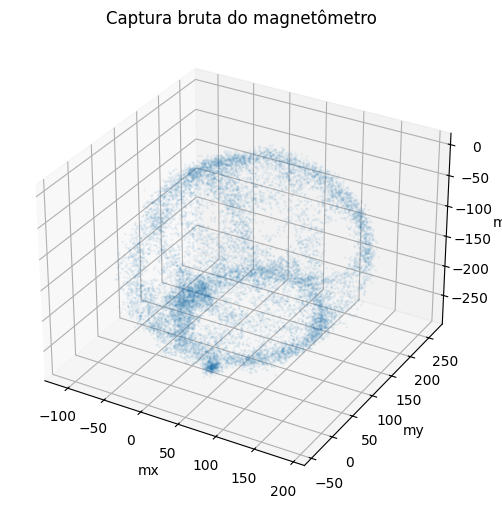

In [207]:
# Visualização 3D da nuvem de pontos brutos (deve parecer um elipsóide deslocado)
fig = plt.figure()
ax = fig.add_subplot(projection="3d")
ax.scatter(captura[:, 0], captura[:, 1], captura[:, 2], alpha=0.05, s=1)
ax.set_xlabel("mx"); ax.set_ylabel("my"); ax.set_zlabel("mz")
ax.set_title("Captura bruta do magnetômetro")
plt.show()

## 4. Função de custo e gradiente

Equação 4.13 com magnitude unitária (`f = 1`); a escala real é absorvida em S e corrigida no fim multiplicando por F.

In [208]:
F_UNITARIO = 1.0

def _monta_S_h(x):
    sxx, syy, szz, sxy, sxz, syz, hx, hy, hz = x
    S = np.array([[sxx, sxy, sxz], [sxy, syy, syz], [sxz, syz, szz]])
    h = np.array([hx, hy, hz])
    return S, h


def costfuncmag(x, data):
    S, h = _monta_S_h(x)
    U = (data - h) @ S  # S simétrica ⇒ S(l-h) por amostra
    R = np.linalg.norm(U, axis=1)
    return np.mean((R - F_UNITARIO) ** 2)


def grad_costfuncmag(x, data):
    sxx, syy, szz, sxy, sxz, syz, hx, hy, hz = x
    S, h = _monta_S_h(x)
    n = data.shape[0]

    diff = data - h
    U = diff @ S    #(n,3)
    R = np.linalg.norm(U, axis=1) #(n,1)
    R = np.where(R < 1e-12, 1e-12, R)
    coef = (2.0 / n) * (R - F_UNITARIO) / R

    g = np.zeros(9)
    g[0] = np.sum(coef * U[:, 0] * diff[:, 0])                                # ∂/∂sxx
    g[1] = np.sum(coef * U[:, 1] * diff[:, 1])                                # ∂/∂syy
    g[2] = np.sum(coef * U[:, 2] * diff[:, 2])                                # ∂/∂szz
    g[3] = np.sum(coef * (U[:, 0] * diff[:, 1] + U[:, 1] * diff[:, 0]))       # ∂/∂sxy
    g[4] = np.sum(coef * (U[:, 0] * diff[:, 2] + U[:, 2] * diff[:, 0]))       # ∂/∂sxz
    g[5] = np.sum(coef * (U[:, 1] * diff[:, 2] + U[:, 2] * diff[:, 1]))       # ∂/∂syz

    SU = U @ S  # ∂R/∂h_k = -SU[:,k] / R
    g[6] = -np.sum(coef * SU[:, 0])
    g[7] = -np.sum(coef * SU[:, 1])
    g[8] = -np.sum(coef * SU[:, 2])
    return g

In [209]:
# Verificação do gradiente por diferenças finitas
def diferencas_finitas(func, x, args=(), eps=1e-6):
    x = np.asarray(x, dtype=float)
    g = np.zeros_like(x)
    for k in range(len(x)):
        passo = np.zeros_like(x); passo[k] = eps
        g[k] = (func(x + passo, *args) - func(x - passo, *args)) / (2 * eps)
    return g

x_teste = np.array([0.005, 0.005, 0.005, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0])
g_ana = grad_costfuncmag(x_teste, captura)
g_num = diferencas_finitas(costfuncmag, x_teste, args=(captura,))
print("Diferença máx. analítico vs. numérico:", np.max(np.abs(g_ana - g_num)))

Diferença máx. analítico vs. numérico: 1.8636543046568477e-06


## 5. Otimização

Chute inicial: ganhos diagonais via amplitude em cada eixo (`sxx ≈ 2/(max−min)`), off-diagonais zero, `h` no centro do intervalo de cada eixo.

In [210]:
lmin = captura.min(axis=0)
lmax = captura.max(axis=0)
sxx0, syy0, szz0 = 2.0 / (lmax - lmin)
hx0, hy0, hz0 = (lmax + lmin) / 2.0
sol_inic = [sxx0, syy0, szz0, 0.0, 0.0, 0.0, hx0, hy0, hz0]
print("Chute inicial:", sol_inic)

cal_mag = scipy.optimize.minimize(
    costfuncmag, sol_inic, captura, jac=grad_costfuncmag
)
print(cal_mag)

Chute inicial: [0.006622516556291391, 0.006472491909385114, 0.007220216606498195, 0.0, 0.0, 0.0, 41.0, 110.5, -140.5]
  message: Optimization terminated successfully.
  success: True
   status: 0
      fun: 0.0018244336369069116
        x: [ 7.127e-03  6.692e-03  8.004e-03 -8.095e-06 -1.827e-05
            -5.090e-04  4.216e+01  1.110e+02 -1.424e+02]
      nit: 47
      jac: [ 1.743e-06  1.371e-06 -3.999e-06  3.344e-06 -4.612e-06
             9.400e-06  4.864e-07 -9.107e-07  3.718e-08]
 hess_inv: [[ 2.842e-04 -7.235e-05 ... -2.776e-01 -3.951e-03]
            [-7.235e-05  2.953e-04 ...  3.161e-01 -5.046e-02]
            ...
            [-2.776e-01  3.161e-01 ...  1.092e+04  1.763e+03]
            [-3.951e-03 -5.046e-02 ...  1.763e+03  2.150e+04]]
     nfev: 59
     njev: 59


## 6. Matrizes S, S' e W

- `S_unit` é a matriz com magnitude unitária; multiplicamos por `F_wmm` para obter a matriz S real.
- `S_prime` converte para o referencial dos sensores inerciais. 
- `Q_FDB` converte para o referencial do robô

In [211]:
S_unit, h = _monta_S_h(cal_mag.x)
S = F_wmm * S_unit
 
R = np.array([[0, 1, 0],
              [1, 0, 0],
              [0, 0, -1]])
S_prime = R @ S      

print("S =\n", S)
print("h =", h)
print("S' =\n", S_prime)

S =
 [[162.35336572  -0.18439767  -0.41616132]
 [ -0.18439767 152.43542854 -11.5953265 ]
 [ -0.41616132 -11.5953265  182.32650991]]
h = [  42.16124924  111.04649021 -142.35053646]
S' =
 [[  -0.18439767  152.43542854  -11.5953265 ]
 [ 162.35336572   -0.18439767   -0.41616132]
 [   0.41616132   11.5953265  -182.32650991]]


In [212]:
Q_path = "/home/mateus/poli_26/elem_robotica/robotica_movel/aula5/Q_FDB.npy"
Q = np.load(Q_path)
print("Q =\n", Q)

W = Q @ S_prime
print("W = Q · S' =\n", W)

Q =
 [[ 9.92657038e-01  7.99896213e-04  1.20960183e-01]
 [ 4.16124223e-03 -9.99612074e-01 -2.75388179e-02]
 [ 1.20891232e-01  2.78399461e-02 -9.92275288e-01]]
W = Q · S' =
 [[-2.83885083e-03  1.52718526e+02 -3.35647634e+01]
 [-1.62302612e+02  4.99325292e-01  5.38880548e+00]
 [ 4.08467029e+00  6.91721712e+00  1.79504731e+02]]


## 7. Validação - 200 amostras com o robô parado


In [99]:
try:
    with urllib.request.urlopen("http://ip-api.com/json/", timeout=5) as req:
        geodata = json.loads(req.read().decode())
    if geodata.get("status") != "success":
        raise RuntimeError(geodata)
    lat, lon, cidade = geodata["lat"], geodata["lon"], geodata["city"]
except Exception as e:
    print(f"ip-api falhou ({e}); usando POLI-USP")
    lat, lon, cidade = -23.5558, -46.7308, "São Paulo (POLI-USP)"
print(f"Local: {cidade} (lat={lat:.4f}, lon={lon:.4f})")

wmm = ahrs.utils.WMM()
wmm.magnetic_field(lat, lon)
F_wmm = float(wmm.F)  # módulo do campo local (mesma unidade que o WMM devolve)
H_wmm = float(wmm.H)
Z_wmm = float(wmm.Z)
I_wmm = float(wmm.I)
D_wmm = float(wmm.D)
print(f"F = {F_wmm:.2f}, H = {H_wmm:.2f}, Z = {Z_wmm:.2f} (unidades do WMM)")
print(f"Inclinação I = {I_wmm:.2f}°, Declinação D = {D_wmm:.2f}°")

Local: São Paulo (lat=-23.6293, lon=-46.6351)
F = 22788.66, H = 17235.35, Z = -14908.58 (unidades do WMM)
Inclinação I = -40.86°, Declinação D = -21.86°


In [ ]:
S_unit, h = _monta_S_h(cal_mag.x)
S = F_wmm * S_unit
 
R = np.array([[0, 1, 0],
              [1, 0, 0],
              [0, 0, -1]])
S_prime = R @ S      

print("S =\n", S)
print("h =", h)
print("S' =\n", S_prime)

S =
 [[ 2.02282538e+02  2.61349331e+00 -2.01138443e-01]
 [ 2.61349331e+00  1.98456169e+02 -1.26944830e+01]
 [-2.01138443e-01 -1.26944830e+01  2.30773693e+02]]
h = [  43.27345129  110.71165811 -132.71058237]
S' =
 [[ 2.61349331e+00  1.98456169e+02 -1.26944830e+01]
 [ 2.02282538e+02  2.61349331e+00 -2.01138443e-01]
 [ 2.01138443e-01  1.26944830e+01 -2.30773693e+02]]


In [187]:
Q_path = "/home/mateus/poli_26/elem_robotica/robotica_movel/aula5/Q_FDB.npy"
Q = np.load(Q_path)
print("Q =\n", Q)

W = Q @ S_prime
print("W = Q · S' =\n", W)

Q =
 [[ 9.92657038e-01  7.99896213e-04  1.20960183e-01]
 [ 4.16124223e-03 -9.99612074e-01 -2.75388179e-02]
 [ 1.20891232e-01  2.78399461e-02 -9.92275288e-01]]
W = Q · S' =
 [[   2.78043731  198.53653056  -40.51585699]
 [-202.19873086   -2.13624633    6.50347031]
 [   5.74789866   11.46794844  227.45078125]]


In [89]:
np.save("W.npy", W)
np.save("h.npy", h)

In [213]:
# Sexta medição (robô parado e nivelado, longe de metais)


#validacao = np.loadtxt(path2) #path2 is the path to the .txt containing 200 samples
#validacao = coleta_magnetometro(200)
path = "/home/mateus/poli_26/elem_robotica/robotica_movel/aula5/dados_magnetometro_200_v2.npy"
validacao = np.load(path)
#validacao = validacao[0:100, :]  #usar só 100 amostras do meio para evitar transientes
print(validacao.shape)
l_medio = validacao.mean(axis=0)
u_local = W @ (l_medio - h)



F_meas = float(np.linalg.norm(u_local)) 
H_meas = float(np.linalg.norm(u_local[:2]))
Z_meas = float(u_local[2])



F_wmm = 22778.664
H_wmm = 17235.350
Z_wmm = -14908.58


print(f"u_local = {u_local}")
print(f"               medido        WMM         erro rel.")
for nome, m, w in [("F", F_meas, F_wmm), ("H", H_meas, H_wmm), ("Z", Z_meas, Z_wmm)]:
    err = (m - w) / w * 100 if w != 0 else float('nan')
    print(f"  {nome}:     {m:12.3f}   {w:12.3f}   {err:+7.2f}%")

(200, 3)
u_local = [ -1399.80653715  -9882.00020069 -17377.59797098]
               medido        WMM         erro rel.
  F:        20039.818      22778.664    -12.02%
  H:         9980.651      17235.350    -42.09%
  Z:       -17377.598     -14908.580    +16.56%


Calibração: |U| média = 0.9982, std = 0.0427, min = 0.8294, max = 1.1580
Validação:  |U| média = 0.8807, std = 0.0319, min = 0.8034, max = 0.9856


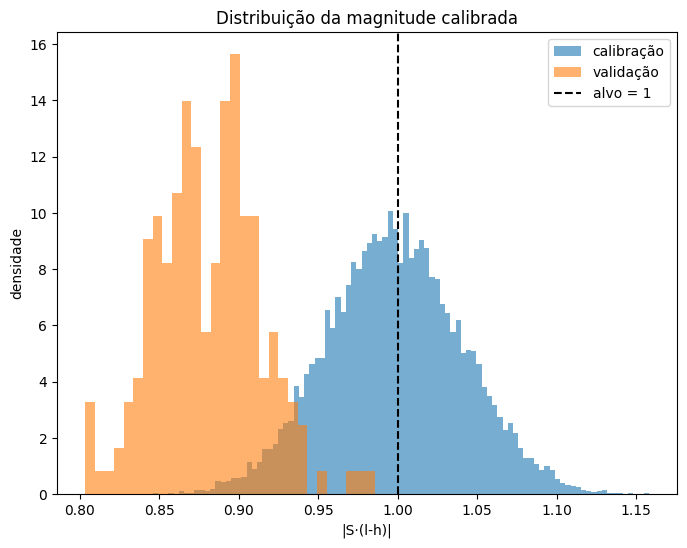

In [214]:
# Diagnóstico: |S_unit·(l-h)| deve ficar próximo de 1 tanto na captura
# de calibração quanto nas amostras de validação. Se a validação cair
# fora da distribuição da calibração, a cobertura de orientações ou o
# ambiente magnético na validação está diferente do da calibração.
S_unit_diag, h_diag = _monta_S_h(cal_mag.x)
mag_cal = np.linalg.norm((captura - h_diag) @ S_unit_diag, axis=1)
mag_val = np.linalg.norm((validacao - h_diag) @ S_unit_diag, axis=1)

print(f"Calibração: |U| média = {mag_cal.mean():.4f}, std = {mag_cal.std():.4f}, "
      f"min = {mag_cal.min():.4f}, max = {mag_cal.max():.4f}")
print(f"Validação:  |U| média = {mag_val.mean():.4f}, std = {mag_val.std():.4f}, "
      f"min = {mag_val.min():.4f}, max = {mag_val.max():.4f}")

plt.hist(mag_cal, bins=100, alpha=0.6, label="calibração", density=True)
plt.hist(mag_val, bins=30, alpha=0.6, label="validação", density=True)
plt.axvline(1.0, color="k", linestyle="--", label="alvo = 1")
plt.legend(); plt.xlabel("|S·(l-h)|"); plt.ylabel("densidade")
plt.title("Distribuição da magnitude calibrada")
plt.show()

F_wmm = 22778.66 nT

Calibração (15.000 amostras):
  |u_robot| média =   22737.11 nT   (-0.18% vs WMM)
  erro absoluto:   média =   -41.56 nT, std = 972.07 nT
  erro |.|:         média = 776.99 nT

Validação (200 amostras):
  |u_robot| média =   20060.39 nT   (-11.93% vs WMM)
  erro absoluto:   média = -2718.27 nT, std = 727.59 nT
  erro |.|:         média = 2718.27 nT


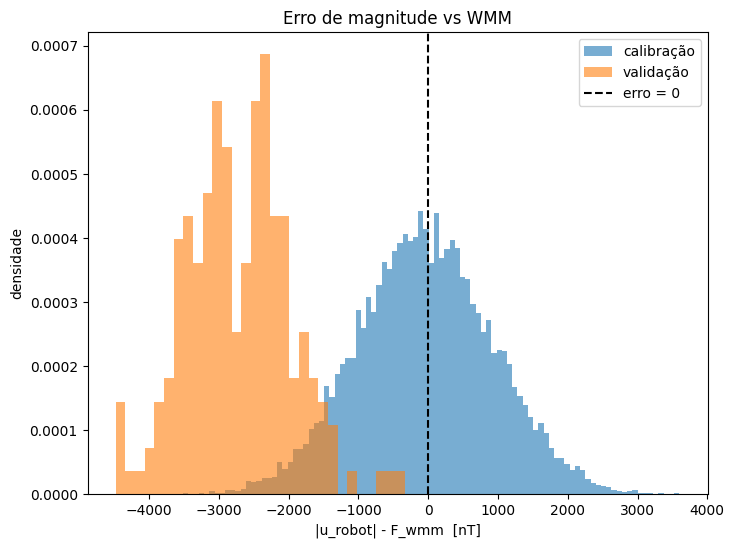

In [215]:
# Erro de magnitude por amostra: |u_robot| (em nT) versus F_wmm.
# Como a |F| é invariante por rotação, isso é a única comparação direta
# que faz sentido nos dados de calibração (o robô gira durante a captura,
# então H e Z no referencial do robô mudam a cada amostra).
u_cal = (captura - h) @ W.T            # u_robot = W @ (l - h), por linha
u_val = (validacao - h) @ W.T

F_cal = np.linalg.norm(u_cal, axis=1)
F_val = np.linalg.norm(u_val, axis=1)

err_cal = F_cal - F_wmm
err_val = F_val - F_wmm

print(f"F_wmm = {F_wmm:.2f} nT\n")
print("Calibração (15.000 amostras):")
print(f"  |u_robot| média = {F_cal.mean():10.2f} nT   ({(F_cal.mean()/F_wmm-1)*100:+.2f}% vs WMM)")
print(f"  erro absoluto:   média = {err_cal.mean():+8.2f} nT, std = {err_cal.std():.2f} nT")
print(f"  erro |.|:         média = {np.abs(err_cal).mean():.2f} nT")
print()
print("Validação (200 amostras):")
print(f"  |u_robot| média = {F_val.mean():10.2f} nT   ({(F_val.mean()/F_wmm-1)*100:+.2f}% vs WMM)")
print(f"  erro absoluto:   média = {err_val.mean():+8.2f} nT, std = {err_val.std():.2f} nT")
print(f"  erro |.|:         média = {np.abs(err_val).mean():.2f} nT")

plt.hist(err_cal, bins=100, alpha=0.6, label="calibração", density=True)
plt.hist(err_val, bins=30, alpha=0.6, label="validação", density=True)
plt.axvline(0.0, color="k", linestyle="--", label="erro = 0")
plt.legend(); plt.xlabel("|u_robot| - F_wmm  [nT]"); plt.ylabel("densidade")
plt.title("Erro de magnitude vs WMM")
plt.show()

magnetometro_bruto.npy: shape = (15000, 3), std por eixo = [63.11 72.41  6.4 ]  (z baixo ⇒ yaw dominante)

Validação em magnetometro_bruto.npy (15000 amostras):
               média        std       WMM         erro rel.
  F:     20007.12   1076.75    22778.66   -12.17%
  H:     16875.78   1176.64    17235.35    -2.09%
  Z:    -10678.06   1116.50   -14908.58   -28.38%


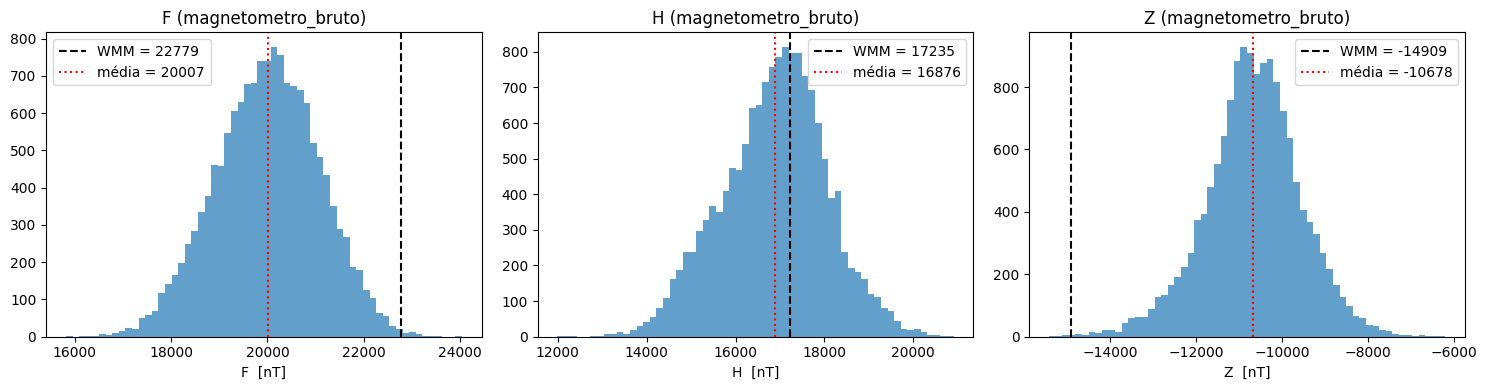

In [216]:
# Validação alternativa usando magnetometro_bruto.npy (rotação ~ pura em yaw).
# Como z_robot é o eixo de rotação, ele não muda no referencial do mundo, então:
#   - u_z deve ser ~constante e ≈ Z_wmm (se o robô estiver nivelado)
#   - |(u_x, u_y)| deve ser ~constante e ≈ H_wmm
#   - |u| deve ser sempre ≈ F_wmm (invariante por rotação)
path_bruto = "/home/mateus/poli_26/elem_robotica/robotica_movel/aula5/magnetometro_bruto.npy"
bruto = np.load(path_bruto)
#bruto = bruto[7500:7600,: ]
print(f"magnetometro_bruto.npy: shape = {bruto.shape}, "
      f"std por eixo = {bruto.std(axis=0).round(2)}  (z baixo ⇒ yaw dominante)")

u_b = (bruto - h) @ W.T
F_b = np.linalg.norm(u_b, axis=1)
H_b = np.linalg.norm(u_b[:, :2], axis=1)
Z_b = u_b[:, 2]


print(f"\nValidação em magnetometro_bruto.npy ({len(bruto)} amostras):")
print(f"               média        std       WMM         erro rel.")
for nome, m_arr, w in [("F", F_b, F_wmm), ("H", H_b, H_wmm), ("Z", Z_b, Z_wmm)]:
    err = (m_arr.mean() - w) / w * 100 if w != 0 else float("nan")
    print(f"  {nome}:   {m_arr.mean():10.2f}  {m_arr.std():8.2f}  {w:10.2f}  {err:+7.2f}%")

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, vals, ref, nome in zip(axes, [F_b, H_b, Z_b], [F_wmm, H_wmm, Z_wmm], ["F", "H", "Z"]):
    ax.hist(vals, bins=60, alpha=0.7)
    ax.axvline(ref, color="k", linestyle="--", label=f"WMM = {ref:.0f}")
    ax.axvline(vals.mean(), color="r", linestyle=":", label=f"média = {vals.mean():.0f}")
    ax.set_xlabel(f"{nome}  [nT]"); ax.set_title(f"{nome} (magnetometro_bruto)"); ax.legend()
plt.tight_layout(); plt.show()

## 4.5 - Estimativa do rumo do robô

In [247]:
l_rumo = np.load("/home/mateus/poli_26/elem_robotica/robotica_movel/aula5/magnetometro_bruto.npy")
print(l_rumo.shape)

(15000, 3)


In [249]:
print(h.shape)
print(W.shape)

(3,)
(3, 3)


(15000,)
(15000,)
(15000,)


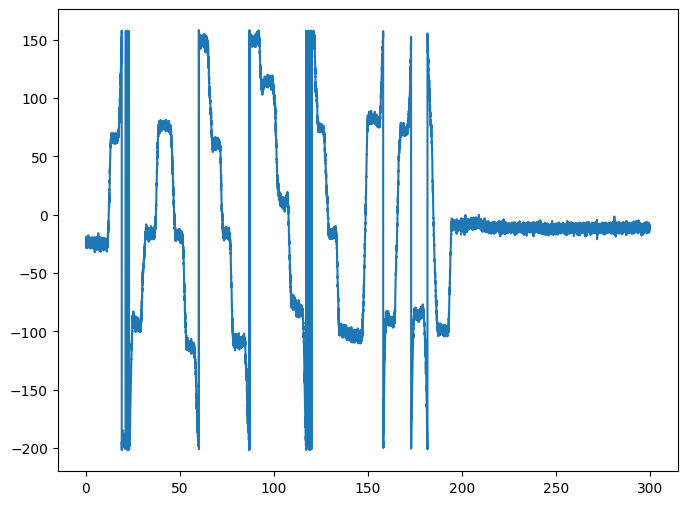

In [ ]:
D = -21.86 
u_rumo = W @ (l_rumo - h.T).T
phi = np.arctan2(u_rumo[1], u_rumo[0]) * 180 / np.pi
rumo = D - phi
rumo = rumo.squeeze()

t = np.linspace(0, 1/50 * (len(rumo) - 1), len(rumo))  

plt.plot(t, rumo)
